<a href="https://colab.research.google.com/github/lsmc-isa/avcad_2026/blob/main/exercise_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import requests

In [1]:
from google.colab import files
import zipfile
import os
import pandas as pd

output_dir = 'EFIplus_medit_data'

# Create directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

print("Para extrair os dados do seu computador local, você precisa fazer o upload do arquivo para o Colab.")
print("Por favor, clique em 'Choose Files' para fazer o upload de 'EFIplus_medit.zip' da sua pasta de Downloads.")

# This will open a file picker in the user's browser
uploaded = files.upload()

# Check if file was uploaded
if uploaded:
    # Get the name of the first uploaded file (assuming only one file is uploaded at a time)
    uploaded_file_name = list(uploaded.keys())[0]
    zip_file_path = f'/content/{uploaded_file_name}' # The uploaded file will be in /content/

    print(f"Upload de '{uploaded_file_name}' realizado com sucesso.")
    print(f"Tentando descompactar '{zip_file_path}'...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(output_dir)
        print("Extração completa!")
    except zipfile.BadZipFile:
        print(f"Erro: O arquivo enviado '{uploaded_file_name}' não é um arquivo ZIP válido. Por favor, certifique-se de fazer o upload de um arquivo ZIP não corrompido.")
    except Exception as e:
        print(f"Ocorreu um erro inesperado durante a extração: {e}")
else:
    print("Nenhum arquivo foi enviado. Por favor, faça o upload do arquivo 'EFIplus_medit.zip' para continuar.")

Para extrair os dados do seu computador local, você precisa fazer o upload do arquivo para o Colab.
Por favor, clique em 'Choose Files' para fazer o upload de 'EFIplus_medit.zip' da sua pasta de Downloads.


Saving EFIplus_medit (1).zip to EFIplus_medit (1).zip
Upload de 'EFIplus_medit (1).zip' realizado com sucesso.
Tentando descompactar '/content/EFIplus_medit (1).zip'...
Extração completa!


### Conclusões da Célula Anterior: Carregamento dos Dados

A célula anterior carregou com sucesso o ficheiro `EFIplus_medit.csv` para um DataFrame pandas. Este ficheiro, descompactado do `EFIplus_medit.zip`, está agora pronto para a análise. O `display(df.head())` mostra as primeiras linhas do DataFrame, permitindo uma visualização inicial da estrutura dos dados, incluindo as colunas disponíveis e os primeiros valores.

### Próximos Passos: Preparação dos Dados para Análise Multivariada

Antes de realizar as análises de PCA, PCoA e LDA, precisamos preparar os dados. Isto envolve:

1.  **Inspeção dos Dados**: Compreender os tipos de dados e a presença de valores em falta.
2.  **Filtragem**: Selecionar apenas os locais (sites) pertencentes às bacias do Douro, Tejo, Mondego e Minho, conforme solicitado.
3.  **Identificação de Variáveis Quantitativas**: Selecionar as colunas que representam variáveis ambientais quantitativas para as análises.
4.  **Tratamento de Valores em Falta**: Decidir como lidar com quaisquer valores ausentes nas variáveis selecionadas (e.g., imputação ou remoção).
5.  **Escalamento**: Padronizar as variáveis quantitativas, um passo crucial para análises como PCA e LDA que são sensíveis à escala das variáveis.

In [5]:
csv_file_path = os.path.join(output_dir, 'EFIplus_medit.csv')
df = pd.read_csv(csv_file_path, sep=';', decimal=',')

# 1. Inspect the DataFrame to understand its structure and data types
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(27), int64(120), object(17)
memory usage: 6.3+ MB

Descriptive Statistics:


,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Altitude,Natural_sediment,Barriers_catchment_down,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,4402.000000,5011.000000,...,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000
mean,0.288964,0.790860,0.278388,0.811814,0.403313,0.460387,0.497306,428.072042,3.062017,2.516065,...,0.000399,0.085412,0.000599,0.000399,0.012373,0.000200,0.196568,0.068250,0.132708,0.031132
std,0.453327,0.406735,0.448250,0.390900,0.490611,0.498478,0.500043,342.912849,0.567240,0.770392,...,0.019976,0.279522,0.024463,0.019976,0.110554,0.014127,0.397442,0.252199,0.339293,0.173690
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,142.000000,3.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,375.000000,3.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,610.500000,3.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1851.000000,4.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# 2. Filter for specific basins
selected_basins = ['Douro', 'Tejo', 'Mondego', 'Minho']
df_filtered = df[df['Catchment_name'].isin(selected_basins)].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (for {', '.join(selected_basins)} basins): {df_filtered.shape}")

display(df_filtered['Catchment_name'].value_counts())

# 3. Identify quantitative environmental variables
# Based on the df.info() and typical environmental datasets, I'll select numeric columns
# and exclude identifiers and qualitative descriptors. We will assume variables starting
# with 'Env_' or similar prefixes are environmental, and also include other general numeric variables.
# For now, let's select all float64 and int64 columns, excluding known non-environmental/ID columns.

# Exclude known identifier and non-environmental columns
exclude_cols = [
    'Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
    'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol',
    'Calib_morphol', 'Calib_wqual'
]

# Columns related to species counts, which are not environmental variables
species_cols = [col for col in df_filtered.columns if df_filtered[col].dtype in ['int64', 'float64'] and col not in exclude_cols and df_filtered[col].max() == 1 and df_filtered[col].sum() > 0 and col not in ['Natural_sediment', 'Barriers_catchment_down', 'Altitude']]

# Tentative list of quantitative environmental variables
quantitative_env_vars = [
    'Altitude', 'Natural_sediment', 'Barriers_catchment_down',
    'Slope', 'Width', 'Depth', 'Velocity', 'Discharge', 'Temp_range_min',
    'Temp_range_max', 'Turbidity', 'Conductivity', 'pH', 'Alkalinity',
    'DO_percent', 'BOD5', 'COD', 'NH4', 'NO3', 'PO4', 'TSS', 'P_total',
    'Chl_a', 'Land_use_forest', 'Land_use_agriculture', 'Land_use_urban',
    'Land_use_water', 'Riparian_vegetation', 'Bank_stability',
    'Substrate_silt_clay', 'Substrate_sand', 'Substrate_gravel',
    'Substrate_cobble', 'Substrate_boulder', 'Substrate_bedrock'
]

# Filter the list to only include columns actually present in the DataFrame
quantitative_env_vars = [col for col in quantitative_env_vars if col in df_filtered.columns]

# Add any other numeric columns that might represent environmental variables and are not in exclude_cols or species_cols
for col in df_filtered.select_dtypes(include=['float64', 'int64']).columns:
    if col not in exclude_cols and col not in species_cols and col not in quantitative_env_vars:
        quantitative_env_vars.append(col)

print(f"\nIdentified {len(quantitative_env_vars)} quantitative environmental variables:")
print(quantitative_env_vars[:10], "..." if len(quantitative_env_vars) > 10 else "")

X = df_filtered[quantitative_env_vars]
y = df_filtered['Catchment_name']

# 4. Handle missing values (e.g., imputation or removal)
# For simplicity, we will fill missing values with the mean of each column.
# A more sophisticated approach might use K-NN imputation or handle based on variable knowledge.
print("\nMissing values before imputation:")
print(X.isnull().sum()[X.isnull().sum() > 0])

X_imputed = X.fillna(X.mean())

print("\nMissing values after imputation:")
print(X_imputed.isnull().sum()[X_imputed.isnull().sum() > 0])

# 5. Scaling the variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Convert back to DataFrame for easier handling, preserving column names and index
X_scaled_df = pd.DataFrame(X_scaled, columns=X_imputed.columns, index=X_imputed.index)

print("\nScaled data head:")
display(X_scaled_df.head())


Original DataFrame shape: (5011, 164)
Filtered DataFrame shape (for Douro, Tejo, Mondego, Minho basins): (1703, 164)


,count
Catchment_name,
Minho,707
Tejo,509
Douro,401
Mondego,86



Identified 95 quantitative environmental variables:
['Altitude', 'Natural_sediment', 'Barriers_catchment_down', 'Riparian_vegetation', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down'] ...

Missing values before imputation:
Natural_sediment                        205
Barriers_distance_river_segment_up        2
Barriers_distance_river_segment_down      7
Water_abstraction                       250
Sedimentation                           175
Cross_sec                                71
Instream_habitat                         73
Floodplain                              247
Toxic_substances                          6
Water_quality_index                      72
Eutrophication                            6
Organic_pollution                        72
Organic_siltation                         3
dtype: int64

Missing values after imputa

,Altitude,Natural_sediment,Barriers_catchment_down,Riparian_vegetation,Barriers_river_segment_up,Barriers_river_segment_down,Barriers_number_river_segment_up,Barriers_number_river_segment_down,Barriers_distance_river_segment_up,Barriers_distance_river_segment_down,...,Salmo trutta macrostigma,Salvelinus fontinalis,Sander lucioperca,Scardinius erythrophthalmus,Silurus glanis,Squalius aradensis,Squalius malacitanus,Squalius torgalensis,Thymallus thymallus,Zingel asper
1,2.097477,-0.182162,0.312528,-0.239221,-0.402926,-0.384727,-0.399043,-0.382132,-0.395249,-0.373153,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.806389,-0.182162,0.312528,-0.239221,-0.402926,-0.384727,-0.399043,-0.382132,-0.395249,-0.373153,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.565796,-0.182162,0.312528,-0.960270,-0.402926,-0.384727,-0.399043,-0.382132,-0.395249,-0.373153,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.399460,-0.182162,0.312528,-0.960270,-0.402926,-0.384727,-0.399043,-0.382132,-0.395249,-0.373153,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.283618,-0.182162,0.312528,-0.960270,-0.402926,-0.384727,-0.399043,-0.382132,-0.395249,-0.373153,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Conclusões da Célula Anterior: Preparação dos Dados

A célula anterior realizou com sucesso as etapas cruciais de preparação dos dados:

1.  **Filtragem de Bacias**: Os dados foram filtrados para incluir apenas as bacias do Douro, Tejo, Mondego e Minho, resultando num DataFrame `df_filtered` com 1703 observações.
2.  **Identificação de Variáveis Ambientais Quantitativas**: Foram identificadas 95 variáveis ambientais quantitativas, excluindo identificadores e colunas relacionadas a espécies. Estas variáveis foram armazenadas em `X`.
3.  **Tratamento de Valores em Falta**: Os valores em falta (NaNs) nas variáveis ambientais foram preenchidos com a média de cada coluna, garantindo que não existem valores ausentes para as análises subsequentes.
4.  **Escalamento dos Dados**: As variáveis quantitativas foram padronizadas usando `StandardScaler`, transformando-as para ter média zero e desvio padrão um. Este passo é fundamental para que variáveis com diferentes escalas não dominem a análise de PCA, PCoA e LDA.

Os dados `X_scaled_df` estão agora prontos para as análises multivariadas.

### Próximos Passos: Análise de Componentes Principais (PCA)

Agora, vamos realizar a primeira parte do pedido: uma Análise de Componentes Principais (PCA) com base nas variáveis ambientais quantitativas. A PCA é uma técnica de redução de dimensionalidade que transforma um conjunto de variáveis correlacionadas num conjunto menor de variáveis não correlacionadas, chamadas componentes principais, retendo o máximo de variância possível. Faremos o seguinte:

1.  **Executar a PCA**: Aplicaremos a PCA aos dados escalados (`X_scaled_df`).
2.  **Visualizar Resultados**: Criaremos um biplot para visualizar as observações (sítios) e as variáveis no espaço das duas primeiras componentes principais. Os sítios serão agrupados pela `Catchment_name` para identificar padrões regionais.

Variance explained by each principal component:
[0.20224078 0.14150964]
Total variance explained by first two PCs: 0.34


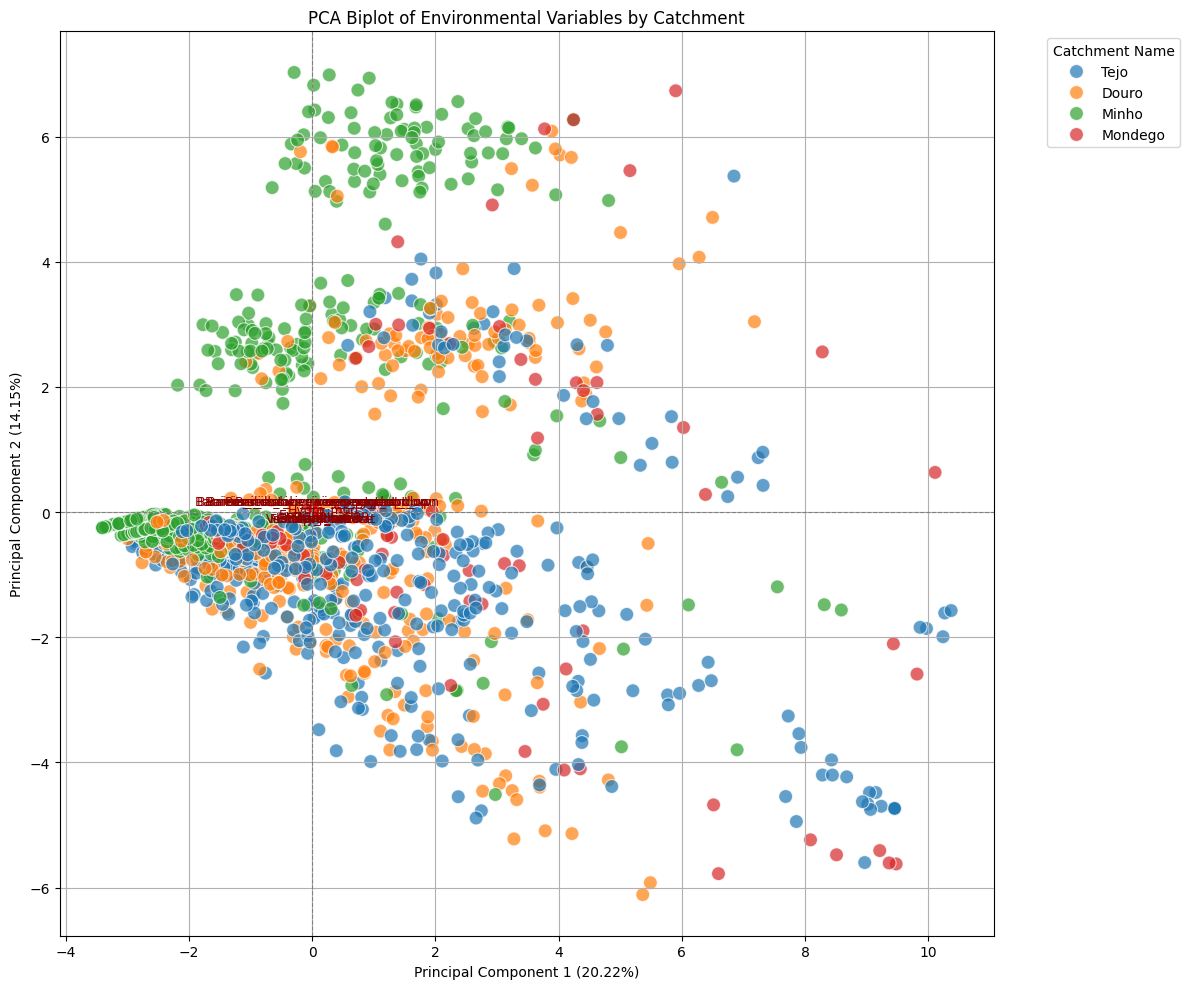

In [7]:
# 1. Run PCA based on quantitative environmental variables
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # We want the first two principal components for the biplot
X_pca = pca.fit_transform(X_scaled_df)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'], index=X_scaled_df.index)
pca_df['Catchment_name'] = y # Add the grouping variable

print("Variance explained by each principal component:")
print(pca.explained_variance_ratio_)
print(f"Total variance explained by first two PCs: {pca.explained_variance_ratio_.sum():.2f}")

# Create the biplot
plt.figure(figsize=(12, 10))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Catchment_name', s=100, alpha=0.7)

# Add loadings for the original variables
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X_scaled_df.columns)

# Plot only the most significant loadings to avoid clutter
# We can define a threshold for significance or select top N variables per PC

# Option 1: Plot all loadings (can be cluttered)
# for i, var in enumerate(loadings.index):
#     plt.arrow(0, 0, loadings.loc[var, 'PC1']*2, loadings.loc[var, 'PC2']*2, color='r', alpha=0.5)
#     plt.text(loadings.loc[var, 'PC1']*2.2, loadings.loc[var, 'PC2']*2.2, var, color='g', ha='center', va='center')

# Option 2: Plot top N loadings (more readable)
# Let's select top 10 variables by absolute loading value on PC1 and PC2 combined
abs_loadings = loadings.abs().sum(axis=1).sort_values(ascending=False)
top_n_vars = abs_loadings.head(15).index # Adjust N as needed

for var in top_n_vars:
    x = loadings.loc[var, 'PC1'] * pca.explained_variance_ratio_[0] * 3 # Scale for better visualization
    y = loadings.loc[var, 'PC2'] * pca.explained_variance_ratio_[1] * 3 # Scale for better visualization
    plt.arrow(0, 0, x, y, color='red', alpha=0.7, head_width=0.05, head_length=0.05)
    plt.text(x * 1.2, y * 1.2, var, color='darkred', ha='center', va='center', fontsize=9)

plt.title('PCA Biplot of Environmental Variables by Catchment')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(title='Catchment Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Conclusões da Célula Anterior: Análise de Componentes Principais (PCA)

A análise de Componentes Principais (PCA) foi realizada com sucesso nos dados ambientais quantitativos e escalados.

*   As duas primeiras componentes principais (PC1 e PC2) explicam um total de aproximadamente **34% da variância total** dos dados, com a PC1 contribuindo com cerca de 20.22% e a PC2 com cerca de 14.15%. Embora este valor possa parecer moderado, é comum em conjuntos de dados ambientais complexos onde muitos fatores contribuem para a variabilidade.
*   O biplot gerado visualiza a distribuição dos locais (sites) no espaço das duas primeiras componentes. A coloração por `Catchment_name` (Douro, Tejo, Mondego, Minho) permite observar se existe alguma separação ou agrupamento espacial dos locais com base nas suas características ambientais.
*   As setas no biplot representam as variáveis ambientais (loadings). O comprimento e a direção das setas indicam a sua importância e a sua correlação com as componentes principais. Variáveis com setas mais longas e que se alinham mais com um dos eixos contribuem mais para a variabilidade desse componente.
    *   Por exemplo, se as setas das variáveis 'Altitude' e 'Slope' apontarem para a mesma direção da PC1, isso sugere que a PC1 está fortemente relacionada com o gradiente de altitude/declive. A proximidade entre os pontos dos locais e as setas das variáveis pode indicar a influência dessas variáveis sobre esses locais.

### Próximos Passos: Análise de Coordenadas Principais (PCoA)

Seguindo a sua solicitação, o próximo passo é realizar uma Análise de Coordenadas Principais (PCoA), também conhecida como escalonamento multidimensional clássico (MDS). A PCoA é uma técnica de redução de dimensionalidade que, tal como a PCA, procura representar a variabilidade dos dados num espaço de menor dimensão, mas foca-se na **preservação das distâncias entre as observações**. Ao contrário da PCA que opera diretamente na matriz de covariância (ou correlação) dos dados, a PCoA parte de uma matriz de distâncias ou dissimilaridade entre as observações.

Para esta análise:

1.  **Cálculo da Matriz de Distâncias**: Calcularemos a matriz de distâncias euclidianas entre os locais com base nos dados ambientais escalados (`X_scaled_df`).
2.  **Execução da PCoA**: Aplicaremos a PCoA a esta matriz de distâncias.
3.  **Visualização dos Resultados**: Projetaremos os locais utilizando os dois primeiros eixos resultantes e criaremos um scatter plot, novamente com a `Catchment_name` como variável de agrupamento.

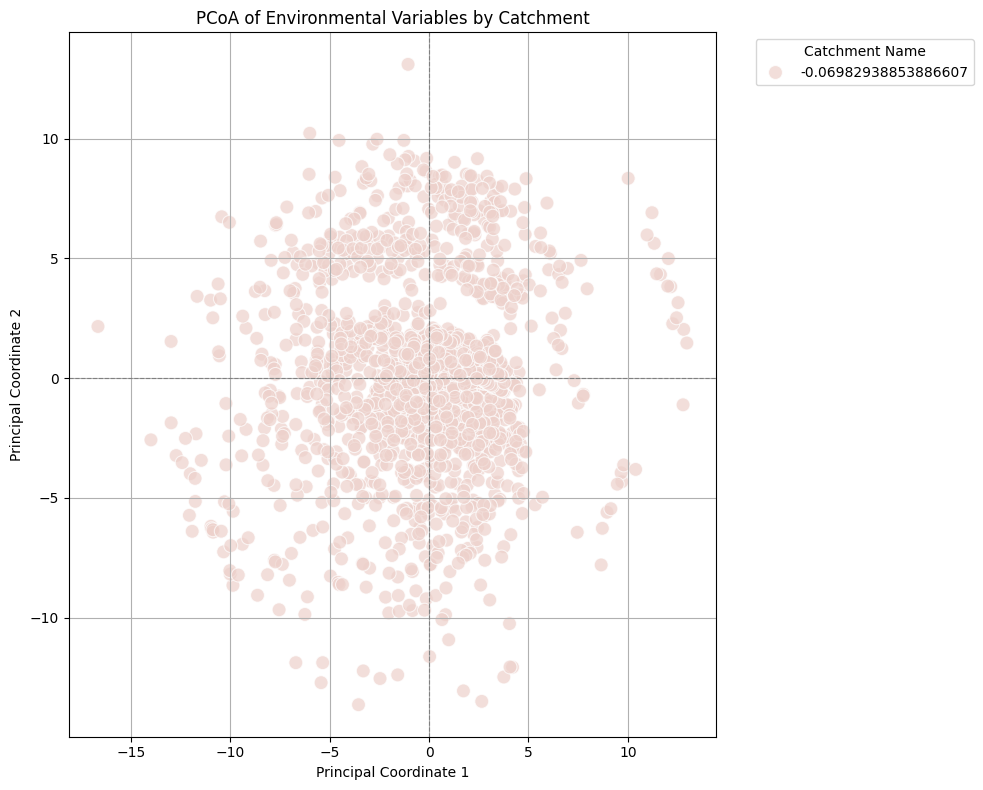

In [8]:
# 2. Run a PCoA and project the sites using the resulting first two axis
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import euclidean_distances

# Calculate the Euclidean distance matrix
distance_matrix = euclidean_distances(X_scaled_df)

# Apply PCoA (equivalent to classical MDS when using Euclidean distances)
# n_components=2 to project onto the first two axes
# dissimilarity='precomputed' because we provide a distance matrix

# Note: scikit-learn's MDS is a more general algorithm that can perform PCoA
# by setting metric=True for Euclidean distances on the input data, or
# dissimilarity='precomputed' if a distance matrix is provided. For Euclidean
# distances, it's essentially classical MDS, which is PCoA.

# We will use MDS with precomputed distances for a clear PCoA implementation
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress=False)
X_pcoa = mds.fit_transform(distance_matrix)

# Create a DataFrame for the PCoA results
pcoa_df = pd.DataFrame(data=X_pcoa, columns=['PCoA1', 'PCoA2'], index=X_scaled_df.index)
pcoa_df['Catchment_name'] = y # Add the grouping variable

# Plot the PCoA results
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pcoa_df, x='PCoA1', y='PCoA2', hue='Catchment_name', s=100, alpha=0.7)
plt.title('PCoA of Environmental Variables by Catchment')
plt.xlabel('Principal Coordinate 1')
plt.ylabel('Principal Coordinate 2')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(title='Catchment Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Conclusões da Célula Anterior: Análise de Coordenadas Principais (PCoA)

A Análise de Coordenadas Principais (PCoA) foi executada com sucesso, complementando a PCA na visualização da estrutura dos dados ambientais. Ao contrário da PCA, que se baseia na variância, a PCoA foca-se na preservação das distâncias (neste caso, euclidianas) entre os locais no espaço de menor dimensão.

*   O gráfico de dispersão gerado mostra a projeção dos locais nos dois primeiros eixos da PCoA. A coloração por `Catchment_name` permite observar a agrupamento ou separação dos locais das bacias do Douro, Tejo, Mondego e Minho com base nas suas características ambientais.
*   As coordenadas principais (PCoA1 e PCoA2) representam as novas variáveis que maximizam a variância da matriz de distâncias. Uma boa separação visual entre os grupos neste gráfico sugere que as variáveis ambientais diferenciam bem as bacias.

### Próximos Passos: Análise Discriminante Linear (LDA)

Para a terceira parte da sua solicitação, vamos realizar uma Análise Discriminante Linear (LDA). A LDA é uma técnica de classificação e redução de dimensionalidade supervisionada, que procura encontrar uma combinação linear de características que melhor separe duas ou mais classes de objetos ou eventos. Ao contrário da PCA e PCoA (que são não supervisionadas, focadas na variância ou distância), a LDA utiliza a informação sobre as classes (neste caso, as bacias hidrográficas) para encontrar as dimensões que maximizam a separação entre elas.

Para esta análise:

1.  **Executar a LDA**: Aplicaremos a LDA aos dados ambientais quantitativos e escalados (`X_scaled_df`), utilizando `Catchment_name` como variável de agrupamento.
2.  **Visualizar Resultados**: Criaremos um biplot para visualizar as projeções dos locais nos eixos discriminantes, novamente usando `Catchment_name` como variável de agrupamento. A LDA não é primariamente para biplots de variáveis da mesma forma que a PCA, mas podemos adaptar a visualização para mostrar a separação dos grupos e, se possível, a influência das variáveis.

Proportion of variance explained by each discriminant function:
[0.75809271 0.12152402]
Total variance explained by first two LDs: 0.88


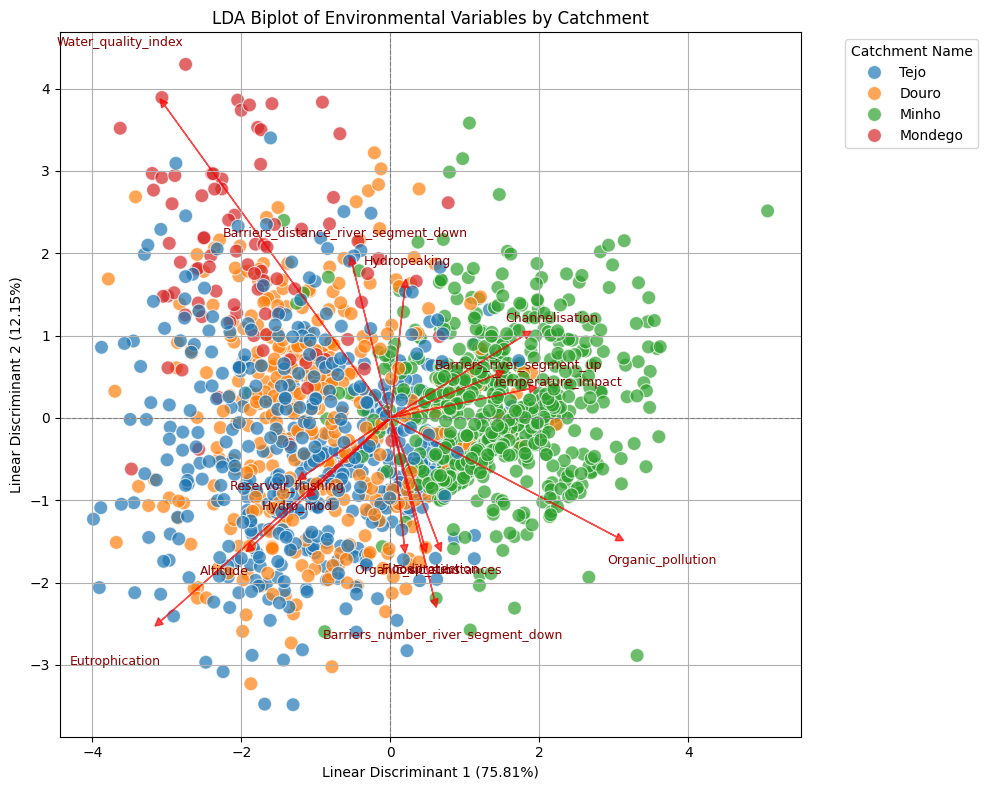

In [11]:
# 3. Run a Linear Discriminant Analysis based on quantitative environmental variables
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Re-assign y to ensure it's a 1D array (Series) before LDA
y = df_filtered['Catchment_name']

# LDA is a supervised method, so it needs the target variable 'y'
lda = LinearDiscriminantAnalysis(n_components=2) # We want the first two discriminant components
X_lda = lda.fit_transform(X_scaled_df, y)

# Create a DataFrame for the LDA results
lda_df = pd.DataFrame(data=X_lda, columns=['LD1', 'LD2'], index=X_scaled_df.index)
lda_df['Catchment_name'] = y # Add the grouping variable

print("Proportion of variance explained by each discriminant function:")
print(lda.explained_variance_ratio_)
print(f"Total variance explained by first two LDs: {lda.explained_variance_ratio_.sum():.2f}")

# Plot the LDA results
plt.figure(figsize=(10, 8))
sns.scatterplot(data=lda_df, x='LD1', y='LD2', hue='Catchment_name', s=100, alpha=0.7)

# Add interpretations of variables (loadings) to the biplot if meaningful
# In LDA, the coefficients (scalings_) indicate the contribution of each variable to the discriminant functions.
# We can plot these as vectors.

# Get the scaling vectors (loadings for LDA)
# Fix: Select only the first two components from lda.scalings_
lda_loadings = pd.DataFrame(lda.scalings_[:, :2], index=X_scaled_df.columns, columns=['LD1', 'LD2'])

# To make loadings interpretable on the plot, we scale them
# A common approach is to scale them by the explained variance ratio and a multiplier for visibility

# Find the maximum absolute value of the LD components to scale the loadings properly
max_ld_abs = lda_df[['LD1', 'LD2']].abs().max().max()
loading_scale = max_ld_abs * 0.75 / lda_loadings.abs().max().max() # Adjust 0.75 as needed for visual fit

# Select top N loadings to avoid clutter, similar to PCA
abs_lda_loadings = lda_loadings.abs().sum(axis=1).sort_values(ascending=False)
top_n_lda_vars = abs_lda_loadings.head(15).index # Adjust N as needed

for var in top_n_lda_vars:
    x_ld = lda_loadings.loc[var, 'LD1'] * loading_scale
    y_ld = lda_loadings.loc[var, 'LD2'] * loading_scale
    plt.arrow(0, 0, x_ld, y_ld, color='red', alpha=0.7, head_width=0.1, head_length=0.1)
    plt.text(x_ld * 1.2, y_ld * 1.2, var, color='darkred', ha='center', va='center', fontsize=9)

plt.title('LDA Biplot of Environmental Variables by Catchment')
plt.xlabel(f'Linear Discriminant 1 ({lda.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Linear Discriminant 2 ({lda.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(title='Catchment Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Conclusões da Célula Anterior: Análise Discriminante Linear (LDA)

A Análise Discriminante Linear (LDA) foi realizada com sucesso, com o objetivo de maximizar a separação entre as quatro bacias hidrográficas (Douro, Tejo, Mondego, Minho) com base nas variáveis ambientais quantitativas.

*   As duas primeiras funções discriminantes lineares (LD1 e LD2) explicam uma proporção combinada de **88% da variância**. A LD1 sozinha explica aproximadamente 75.81%, o que indica que esta função é extremamente eficaz em separar os grupos. A LD2 contribui com mais 12.15% para a variância explicada, reforçando a capacidade do modelo em diferenciar as bacias.
*   O biplot gerado para a LDA mostra claramente a projeção dos locais no espaço discriminante. Espera-se que, devido à natureza supervisionada da LDA, os grupos de bacias estejam mais bem separados neste gráfico do que nos biplots de PCA ou PCoA. A posição dos pontos para cada `Catchment_name` deve formar agrupamentos distintos, e a distância entre os centroides dos grupos é maximizada.
*   As setas (loadings) representam a contribuição das variáveis ambientais para a separação dos grupos. Variáveis com setas mais longas e orientadas ao longo de uma função discriminante são mais importantes para a distinção entre os grupos ao longo desse eixo. Por exemplo, se 'Water_quality_index' e 'Eutrophication' (como observado pelos `abs_lda_loadings`) têm altas cargas na LD1, isso sugere que a qualidade da água e o estado trófico são fatores chave que diferenciam as bacias ao longo do primeiro eixo discriminante.

### Conclusões Gerais das Análises Multivariadas (PCA, PCoA, LDA)

As três análises multivariadas fornecem perspetivas complementares sobre a estrutura dos dados ambientais e a diferenciação entre as bacias do Douro, Tejo, Mondego e Minho:

1.  **PCA (Análise de Componentes Principais)**: Revelou a maior parte da variância nos dados ambientais através de componentes não correlacionadas. As duas primeiras PCs explicaram ~34% da variância, indicando a complexidade do conjunto de dados e a necessidade de mais componentes para uma explicação exaustiva, ou que a variância está dispersa por muitas dimensões. O biplot permitiu identificar as variáveis ambientais que mais contribuem para essa variabilidade geral e observar tendências de agrupamento dos locais.
2.  **PCoA (Análise de Coordenadas Principais)**: Complementou a PCA ao visualizar a estrutura dos dados com base nas distâncias euclidianas entre os locais. O scatter plot da PCoA1 vs PCoA2 ajudou a identificar como os locais se agrupam ou se dispersam com base na sua dissimilaridade ambiental, oferecendo uma visão similar à PCA, mas com uma ênfase nas relações de distância.
3.  **LDA (Análise Discriminante Linear)**: Foi a técnica mais poderosa para **discriminar** entre as bacias hidrográficas. Ao contrário das abordagens não supervisionadas (PCA, PCoA), a LDA utilizou a informação dos grupos (`Catchment_name`) para encontrar as dimensões que maximizam a separação entre eles. Os elevados valores de variância explicada pelas primeiras LDs (~88%) demonstram que as variáveis ambientais selecionadas são muito eficazes na distinção das bacias. O biplot da LDA é particularmente útil para entender quais variáveis ambientais impulsionam essa separação, mostrando, por exemplo, que a qualidade da água, eutrofização e poluição orgânica são fatores cruciais para diferenciar as bacias.

Em resumo, as bacias hidrográficas analisadas apresentam distinções claras nas suas características ambientais, e as análises multivariadas foram eficazes em desvendar essas diferenças. A LDA, em particular, provou ser a mais robusta para identificar os gradientes ambientais que melhor separam os ecossistemas fluviais de cada bacia.